In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import myMVP as mmvp

ModuleNotFoundError: No module named 'myMVP'

In [ ]:
plt.style.use("seaborn")

### Data import

In [ ]:
data = pd.read_csv("/media/chung/Elements/2022/BigData/data/Dow/dow_df.csv", index_col='Date', parse_dates=True)

In [ ]:
data.columns

Index(['DJI', 'MMM', 'AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO',
       'DOW', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'MCD', 'MRK',
       'MSFT', 'NKE', 'PG', 'CRM', 'TRV', 'UNH', 'VZ', 'V', 'WMT', 'WBA'],
      dtype='object')

In [ ]:
#data = data.drop(['DWDP', 'UTX'], axis=1)
dow = data['DJI']
data = data.drop(["DJI"], axis=1)

In [ ]:
ret = data.pct_change().dropna()

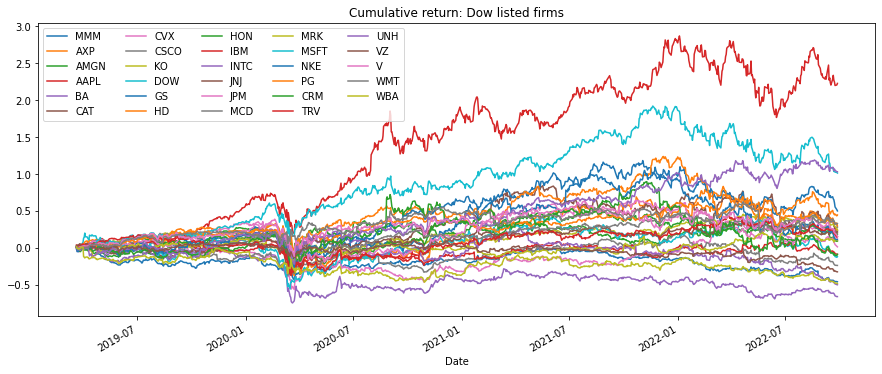

In [ ]:
((1+ret).cumprod() -1).plot(figsize= (15,6))
plt.legend(ncol=5);
plt.title("Cumulative return: Dow listed firms");

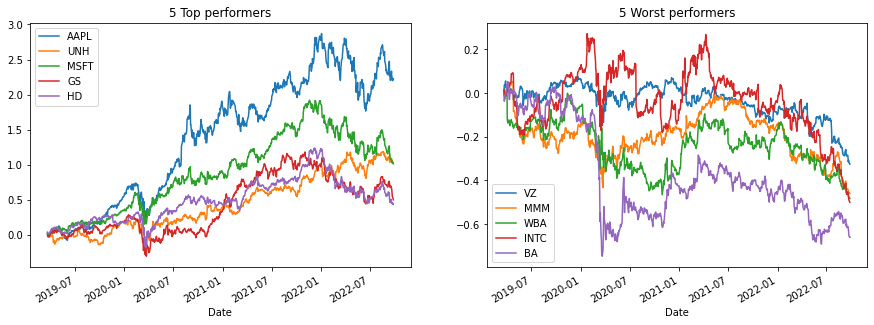

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(15,5))
cum_ret = ((1+ret).cumprod() -1)
idx = cum_ret.iloc[-1, :].argsort()[::-1]
cum_ret.iloc[:, idx[:5]].plot(ax=axs[0])
axs[0].set_title('5 Top performers')
cum_ret.iloc[:, idx[-5:]].plot(ax=axs[1])
axs[1].set_title('5 Worst performers');

<AxesSubplot:>

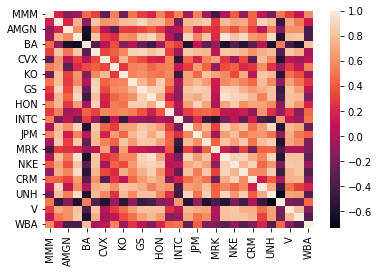

In [ ]:
sns.heatmap(((1+ret).cumprod() -1).corr())

## Minimum Variance without short-sale constraints

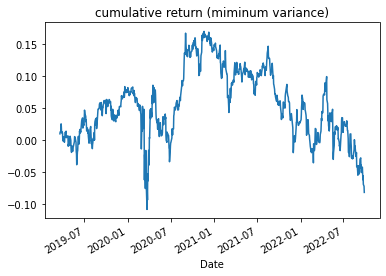

In [ ]:
mv_weight = mmvp.min_var_weight(ret[:2022])
mv_ret = mmvp.cum_return(ret, mv_weight)

mv_ret[:2022].plot()
mv_ret[2022:].plot(c='r');
plt.title('cumulative return (miminum variance)');

<AxesSubplot:>

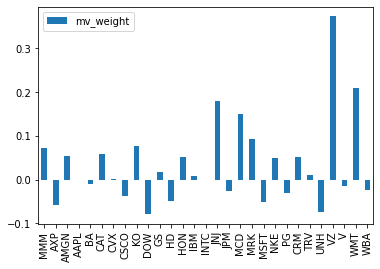

In [ ]:
weights_set = pd.DataFrame().assign(mv_weight=mv_weight.flatten()).set_index(ret.columns)

weights_set.plot(kind='bar')

In [ ]:
weights_set

,mv_weight
MMM,0.071852
AXP,-0.059359
AMGN,0.053335
AAPL,-0.001572
BA,-0.010097
CAT,0.058637
CVX,0.001216
CSCO,-0.036586
KO,0.077694
DOW,-0.079305


In [ ]:
weights_set.sort_values(by=['mv_weight'], ascending=False)

,mv_weight
VZ,0.373135
WMT,0.210357
JNJ,0.180508
MCD,0.150389
MRK,0.092659
KO,0.077694
MMM,0.071852
CAT,0.058637
AMGN,0.053335
HON,0.051111


## MVF with short-sale constraints (for reference)

In [ ]:
import importlib
importlib.reload(mmvp)

<module 'myMVP' from 'd:\\lecture_material\\notebook\\Portfolio\\myMVP.py'>

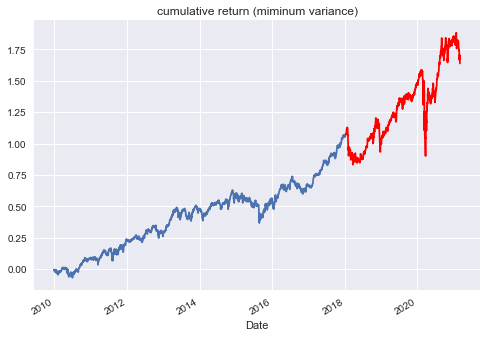

In [ ]:
mv_ns_weight = mmvp.get_weights_wo_short_sale(ret[:2020])

mv_ns_ret = mmvp.cum_return(ret, mv_ns_weight)

mv_ns_ret[:2020].plot()
mv_ns_ret[2020:].plot(c='r');
plt.title('cumulative return (miminum variance)');

In [ ]:
weights_set['mv_ns_weight'] = mv_ns_weight

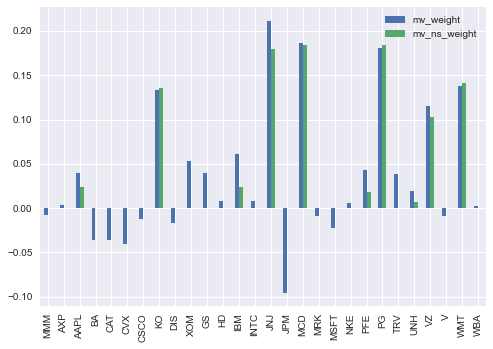

In [ ]:
weights_set.plot(kind='bar');

## Eigenvalue portfolio (for reference)

In [ ]:
ticker, ev_weight = mmvp.largest_eigvalue_weight(ret[:2022])

In [ ]:
!pwd

/media/chung/Elements/2022/BigData/portfolio


WBA


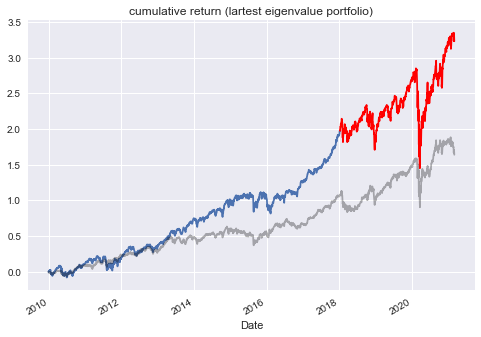

In [ ]:
eig_ret = mmvp.cum_return(ret, ev_weight.reshape(-1,1))

print(ticker)
eig_ret[:2020].plot()
eig_ret[2020:].plot(c='r');
mv_ns_ret.plot(alpha=0.3, c='k')
plt.title('cumulative return (lartest eigenvalue portfolio)');

In [ ]:
weights_set['ev_weight'] = ev_weight

ETF, if existed, is WINNER!!!


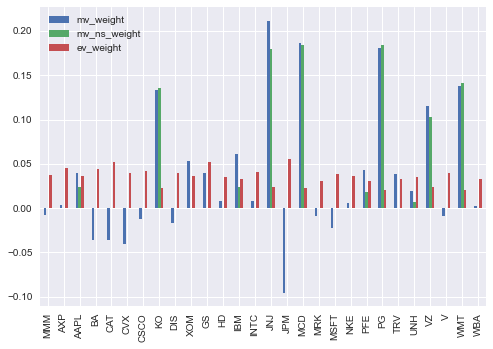

In [ ]:
weights_set.plot(kind='bar');
print('ETF, if existed, is WINNER!!!')

## Some notes on eigenv portfolio

- compare to mean variance portfolio, max. eigenvalue portfolio weights $1/\text{number of assets}=0.036$, that is, __market mode__ and stronly correlated with the market index.
  - market mode: no diversification and only betting on overall market trend, resulting in high risk

- [Bouchaud and Potters(2009)](https://arxiv.org/pdf/0910.1205.pdf) posit that fat tails can massively increase the maximum eigenvalue in the theoretical limiting spectrum of the random matrix


MMM


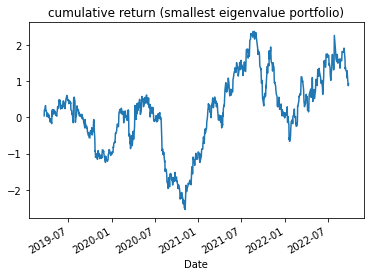

In [ ]:
eig_tickers, eig_weight = mmvp.smallest_eigvalue_weight(ret[:2020])
eig_ret = mmvp.cum_return(ret, eig_weight.reshape(-1,1))

print(eig_tickers)
eig_ret[:2020].plot()
eig_ret[2020:].plot(c='r');
plt.title('cumulative return (smallest eigenvalue portfolio)');

In [ ]:
def min_var_weight(data):
    """
    input:
         data: df return data
    output:
         minimum variance weight
    """

    sigma_inv = np.linalg.inv(data.cov())
    a = np.ones((len(sigma_inv), 1))

    optimal_weight = (np.dot(sigma_inv, a))  / (np.dot(a.T, np.dot(sigma_inv, a)))

    return optimal_weight


def cum_return(ret, weight):
    """
    input:
         data: df return data
    output:
         cumulative return
    """

    ret_ = np.dot(((1+ret).cumprod(axis=0) -1), weight).flatten()

    return pd.Series(data = ret_ , index=ret.index)

import numpy as np

def largest_eigvalue_weight(ret):
    eVal, eVec = np.linalg.eigh(ret.cov())
    idx = eVal.argsort()[::-1]
    eVal = eVal[idx]
    eVec = eVec[:, idx]

    eVec = eVec[:, 0] / eVec[:, 0].sum()

    return ret.columns[idx][0], eVec

def smallest_eigvalue_weight(ret):
    eVal, eVec = np.linalg.eigh(ret.cov())
    idx = eVal.argsort()[::-1]
    eVal = eVal[idx]
    eVec = eVec[:, idx]

    eVec = eVec[:, -1] / eVec[:, -1].sum(axis=0)

    return ret.columns[idx][-1], eVec



In [ ]:
def volatility_opt_fun(weight, ret):
    weight = np.array(weight)
    p_ret = np.sum(ret.mean() * weight) * 250
    p_sigma = np.sqrt(np.dot(weight.T, np.dot(ret.cov() * 250, weight)))

    return np.array(p_sigma **2)


def get_weights_wo_short_sale(ret):
    noa = len(ret.columns)
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) -1}]   # sum(weights)=1
    bounds = tuple((0,1) for x in range(noa))
    vol_out = opt.minimize(lambda *x: volatility_opt_fun(*x), noa * [1. / noa], args= (ret),
                        method='SLSQP', bounds=bounds, constraints=constraints)
    if vol_out['success']:
        weights = vol_out['x']
    else:
        weights = np.nan

    return weights